# YouTube Trending Videos Analysis: What Makes Content Succeed?

##Objective
This project analyzes YouTube trending videos in the United States to identify
which content characteristics — category, title style, publishing timing, video
duration — are associated with videos reaching and staying in the trending list.
The goal is to provide actionable insights for someone starting a new YouTube
channel from scratch.

## Scope and Limitations
- Analysis excludes music content, as it follows different success patterns
  not relevant to a content creator starting from scratch.
- The dataset does not include watch time or retention data — engagement is
  measured as (likes + comments) / views.
- Findings represent correlational patterns, not causal relationships or
  guarantees of success.

In [1]:
!pip install kagglehub
import kagglehub
import pandas as pd
import matplotlib.pyplot as plt
import re
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords
from collections import Counter

pd.options.display.float_format = '{:,.0f}'.format

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [2]:
path = kagglehub.dataset_download("keshavbansal95/youtube-trending-videos-dataset")
df = pd.read_csv(path + '/youtube_trending_3_countries.csv')
print(df.shape)
df.head()

100%|██████████| 261M/261M [00:11<00:00, 24.8MB/s]

Extracting files...


(449791, 28)


,video_id,video_published_at,video_trending__date,video_trending_country,channel_id,video_title,video_description,video_default_thumbnail,video_category_id,video_tags,...,channel_description,channel_custom_url,channel_published_at,channel_country,channel_view_count,channel_subscriber_count,channel_have_hidden_subscribers,channel_video_count,channel_localized_title,channel_localized_description
0,6YMY62tMLUA,2024-10-09T09:00:08Z,2024.10.12,United Arab Emirates,UCq-Fj5jknLsUf-MWSy4_brA,Bhool Bhulaiyaa 3 (Official Trailer): Kartik A...,Haveli Ka Darwaza Khula Ek baar Phir… Rooh Bab...,https://i.ytimg.com/vi/6YMY62tMLUA/default.jpg,Music,"tseries,tseries songs,bhool bhulaiyaa 3,bhool ...",...,"""Music can change the world"". T-Series is Indi...",@tseries,2006-03-13T14:27:05Z,India,"269,373,477,007","276,000,000",False,"21,864",T-Series,"""Music can change the world"". T-Series is Indi..."
1,MD7v0-igVIM,2024-10-07T07:43:56Z,2024.10.12,United Arab Emirates,UCcXQd6kHKm0b41x8zMVMmMg,Singham Again | Official Trailer | A Rohit She...,Aa rahi aap ki favourite cop universe aapke sa...,https://i.ytimg.com/vi/MD7v0-igVIM/default.jpg,Entertainment,"singham again ajay devgn,singam 3 movie,singha...",...,Official Account of JioStudios\n\nwebsite : ht...,@jiostudios,2018-11-05T06:07:05Z,India,"490,715,330","794,000",False,623,JioStudios,Official Account of JioStudios\n\nwebsite : ht...
2,vMqML65MK6Q,2024-10-06T21:00:26Z,2024.10.12,United Arab Emirates,UCf-cpC9WAdOsas19JHipukA,HIGHLIGHTS | Brighton v Tottenham | Premier Le...,#brightonandhovealbion #tottenhamhotspur #pre...,https://i.ytimg.com/vi/vMqML65MK6Q/default.jpg,Sports,"Brighton,Hove,Albion,Premier league,Seagulls,a...",...,Welcome to the official YouTube channel for Br...,@officialbhafc,2013-07-29T09:55:10Z,United Kingdom,"319,492,543","676,000",False,"5,402",Official Brighton & Hove Albion FC,Welcome to the official YouTube channel for Br...
3,AzBz2Va2klU,2024-10-04T14:00:13Z,2024.10.12,United Arab Emirates,UCX5lX80yKjkzyXQWkkm3rOQ,حققت حلم ابني وسافرنا بلد كان نفسة يروحها,حققت حلم ابني وسافرنا بلد كان نفسة يروحها\n\nF...,https://i.ytimg.com/vi/AzBz2Va2klU/default.jpg,Entertainment,"kareem elsayed,kareem elsayed vlogs,diary of a...",...,أسمى كريم السيد.\nمصرى مقيم فى انجلترا.\nفى ال...,@kareemelsayedvlogs,2008-07-26T22:51:16Z,United Kingdom,"171,916,347","1,800,000",False,432,Kareem Elsayed كريم السيد,أسمى كريم السيد.\nمصرى مقيم فى انجلترا.\nفى ال...
4,zxIIKdx61WA,2024-10-01T22:12:30Z,2024.10.12,United Arab Emirates,UC16niRr50-MSBwiO3YDb3RA,Iran threatens new “crushing attack” on Israel...,Iran has threatened to carry out a further “cr...,https://i.ytimg.com/vi/zxIIKdx61WA/default.jpg,News & Politics,"bbc,news,world,america,usa,Vengeance,revenge,L...",...,Welcome to the official BBC News YouTube chann...,@bbcnews,2006-04-08T05:51:05Z,United Kingdom,"5,601,219,393","16,800,000",False,"23,175",BBC News,Welcome to the official BBC News YouTube chann...


In [3]:
# Filtrar a Estados Unidos, excluyendo música
df_usa = df[df['video_trending_country'] == 'United States']
df_usa_not_music = df_usa[df_usa['video_category_id'] != 'Music']

# Quedarse con la primera aparición de cada video en tendencia
df_sort = df_usa_not_music.sort_values(by=['video_id', 'video_trending__date'])
df_first = df_sort.drop_duplicates(subset='video_id', keep='first')

print(f"Total USA (sin música): {df_usa_not_music.shape}")
print(f"Videos únicos (primera aparición): {df_first.shape}")

Total USA (sin música): (5870, 28)
Videos únicos (primera aparición): (1457, 28)


In [4]:
# Eliminar filas con nulos en columnas críticas de engagement
df_first = df_first.dropna(subset=['video_like_count', 'video_comment_count'])

# Rellenar tags vacíos (video sin tags, no un error de captura)
df_first['video_tags'] = df_first['video_tags'].fillna('')

print(f"Videos después de limpieza: {df_first.shape}")

Videos después de limpieza: (1453, 28)


In [5]:
# Cantidad de tags por video
df_first['n_tags'] = df_first['video_tags'].str.split(',').str.len()

# Longitud del título (caracteres)
df_first['title_length'] = df_first['video_title'].str.len()

# Convertir fecha de publicación a datetime
df_first['video_published_at'] = pd.to_datetime(df_first['video_published_at'])
df_first['publish_hour'] = df_first['video_published_at'].dt.hour
df_first['publish_day'] = df_first['video_published_at'].dt.day_name()

# Ratio de engagement
df_first['engagement_ratio'] = (df_first['video_like_count'] + df_first['video_comment_count']) / df_first['video_view_count']

# Duración del video en minutos
df_first['duration_seconds'] = pd.to_timedelta(df_first['video_duration']).dt.total_seconds()
df_first['duration_minutes'] = df_first['duration_seconds'] / 60

df_first[['n_tags', 'title_length', 'publish_hour', 'publish_day', 'engagement_ratio', 'duration_minutes']].head()

,n_tags,title_length,publish_hour,publish_day,engagement_ratio,duration_minutes
4894,23,57,13,Wednesday,0,21
184549,7,36,11,Thursday,0,5
347850,5,54,15,Tuesday,0,30
314198,25,68,16,Tuesday,0,83
276487,1,70,9,Thursday,0,11


In [6]:
# Calcular días en tendencia por video, usando todas las apariciones
dias_en_tendencia = df_usa_not_music['video_id'].value_counts()
dias_en_tendencia_df = dias_en_tendencia.reset_index()
dias_en_tendencia_df.columns = ['video_id', 'dias_en_tendencia']

# Unir con df_first
df_first = df_first.merge(dias_en_tendencia_df, on='video_id')

print(f"Shape final: {df_first.shape}")
df_first[['video_id', 'dias_en_tendencia']].head()

Shape final: (1453, 36)


,video_id,dias_en_tendencia
0,-1Gw3h1X_vk,3
1,-27a1ugJX8U,5
2,-3PDHUg6t4A,1
3,-3XPC7IFOtc,1
4,-3_JlP-ntl4,4


## Analysis 1: Content Category

We first look at which categories dominate the trending list by volume, and
which categories show the strongest relative audience engagement
(likes + comments per view).

video_category_id
Gaming                  598
Sports                  354
Entertainment           179
People & Blogs           99
Autos & Vehicles         66
Film & Animation         45
Comedy                   34
News & Politics          32
Science & Technology     21
Education                13
Travel & Events          11
Pets & Animals            1
Name: count, dtype: int64


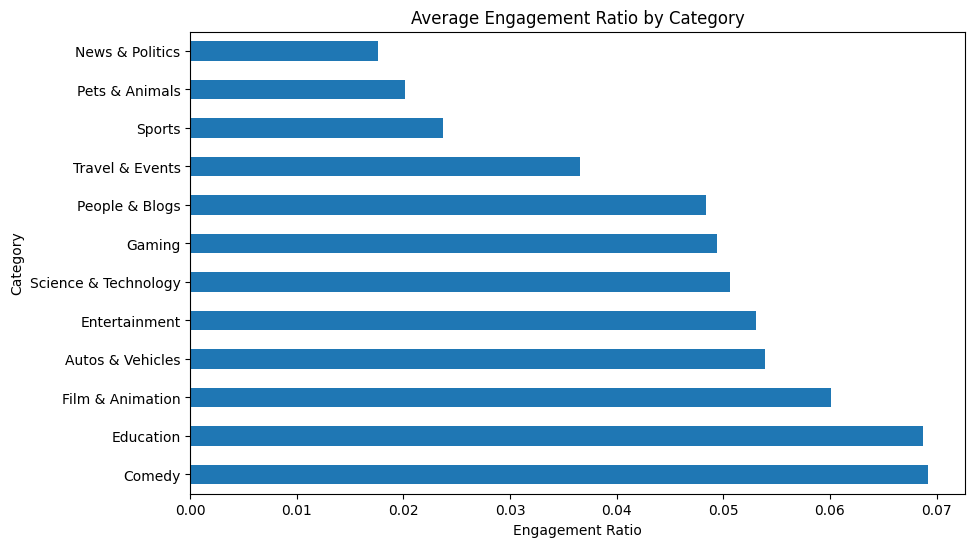

In [7]:
# Volumen de videos por categoría
category_counts = df_first['video_category_id'].value_counts()
print(category_counts)

# Engagement promedio por categoría
category_engagement = df_first.groupby('video_category_id')['engagement_ratio'].mean().sort_values(ascending=False)
category_engagement.plot(kind='barh', figsize=(10,6))
plt.xlabel('Engagement Ratio')
plt.ylabel('Category')
plt.title('Average Engagement Ratio by Category')
plt.show()

We can see which categories have the highest engagement ratio: at the top are
Comedy, Education, and Film & Animation. However, the Education category isn't
reliable, since it only has thirteen videos, below the comparison threshold of
21 videos. Comedy and Film & Animation, on the other hand, can be taken into
account given their larger sample size. Gaming and Sports lead in trending video
volume, but as we can see in the graph, their engagement ratio is roughly half
that of Comedy and Film & Animation. This suggests that for a new creator,
choosing a less saturated category like Comedy or Film & Animation may offer a
better chance of building an actively engaged audience, compared to highly
competitive categories like Gaming.

## Analysis 2: Tags, Title Length, and Video Duration

Next, we examine whether video characteristics — number of tags, title length,
and video duration — show any correlation with view count or engagement.

In [8]:
corr_tags = df_first['n_tags'].corr(df_first['video_view_count'])
corr_title = df_first['title_length'].corr(df_first['video_view_count'])
corr_duration_views = df_first['duration_minutes'].corr(df_first['video_view_count'])
corr_duration_engagement = df_first['duration_minutes'].corr(df_first['engagement_ratio'])

print(f"Tags vs Views: {corr_tags:.3f}")
print(f"Title length vs Views: {corr_title:.3f}")
print(f"Duration vs Views: {corr_duration_views:.3f}")
print(f"Duration vs Engagement: {corr_duration_engagement:.3f}")

Tags vs Views: 0.018
Title length vs Views: 0.231
Duration vs Views: -0.087
Duration vs Engagement: -0.102


We can see that video characteristics show a weak correlation overall. The
highest correlation is between title length and views, at 0.231 — as titles
get longer, views tend to increase slightly. However, none of these
correlations are strong enough to be taken as a reliable rule, since they
are far from 0.5, where a strong relationship would be evident. We can also
see something important: the negative sign for Duration vs Views (-0.087)
and Duration vs Engagement (-0.102) tells us that as video duration
increases, views and engagement tend to slightly decrease. This should be
read as a weak tendency, not a strong effect. Given the weak positive
correlation with title length, a new creator might consider using longer
titles. Given the weak negative correlation with video duration, favoring
shorter videos may offer a slight advantage in views and engagement.

## Analysis 3: Publishing Day and Hour

We now examine whether the day of the week or hour of publication (UTC) shows
any relationship with view count.

In [9]:
day_stats = df_first.groupby('publish_day')['video_view_count'].agg(['mean', 'count']).sort_values(by='count', ascending=False)
print(day_stats)

                 mean  count
publish_day                 
Sunday      1,315,440    268
Tuesday     1,031,772    223
Saturday    1,503,250    208
Wednesday   1,103,252    206
Thursday    1,044,413    189
Monday      1,400,954    182
Friday      1,206,415    177


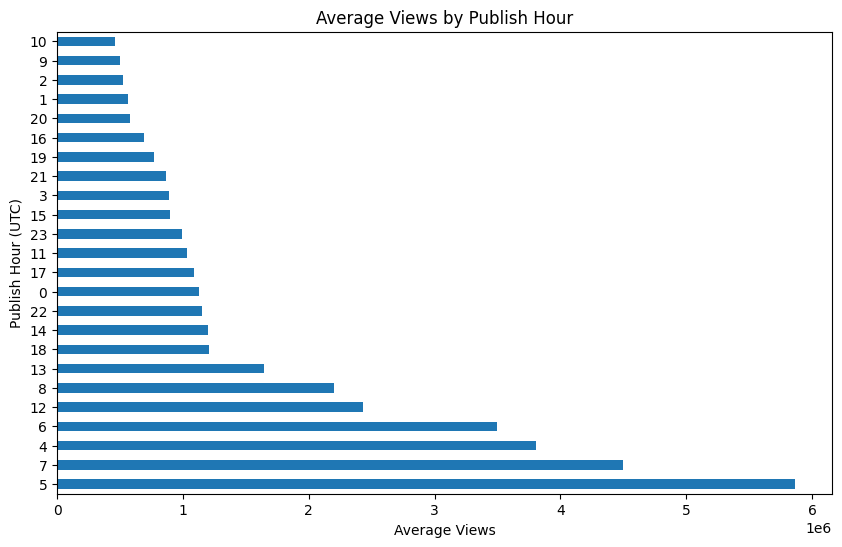

publish_hour
18    170
17    149
19    133
16    130
20    101
15     89
21     88
22     82
14     67
12     64
13     63
11     43
10     39
23     37
0      35
5      30
9      28
8      26
7      15
4      14
6      14
1      13
2      12
3      11
Name: video_view_count, dtype: int64


In [10]:
hour_mean = df_first.groupby('publish_hour')['video_view_count'].mean().sort_values(ascending=False)
hour_mean.plot(kind='barh', figsize=(10,6))
plt.xlabel('Average Views')
plt.ylabel('Publish Hour (UTC)')
plt.title('Average Views by Publish Hour')
plt.show()

hour_count = df_first.groupby('publish_hour')['video_view_count'].count().sort_values(ascending=False)
print(hour_count)

Looking at publishing day, Sunday (268 videos) and Tuesday (223 videos) had the
highest number of uploads, but interestingly, their average views (1,315,440 and
1,031,772 respectively) were not the best. Saturday and Monday actually
outperformed them by roughly 100k-200k views on average — a difference that,
while not huge, is still worth taking into account.

Looking at publishing hour, hour 5 and hour 7 initially appeared to be the best,
combining high average views with a strong upload count. However, with only 30
and 15 videos respectively, further investigation revealed that these samples
were dominated by Bollywood trailer content — not representative of an
independent creator's content. These hours were therefore discarded. Hours 4 and
6 show a similar pattern (high average views, low video count) and likely share
the same bias, although they weren't investigated in the same depth.

Hour 12 also showed a strong average, but with only 64 videos, the sample is too
small to be considered reliable. Taking both average views and sample size into
account, hour 18 (6 PM) stands out as the most reliable choice: it has the
highest video count in the dataset (170) combined with a solid average view
count, making it a safer recommendation for a new creator than hours with higher
but less reliable averages.

## Analysis 4: Common Words in Video Titles

We analyze the most frequent words in trending video titles (excluding common
stopwords) to identify patterns in how successful titles are structured.

In [11]:
todos_titulos = ' '.join(df_first['video_title'].str.lower())
titulos_limpios = re.sub(r'[^a-z0-9\s]', '', todos_titulos)
palabras = titulos_limpios.split()

stop_words = set(stopwords.words('english'))
palabras_limpias = [palabra for palabra in palabras if palabra not in stop_words and not palabra.isdigit()]

conteo_palabras = Counter(palabras_limpias)
palabras_frecuentes = conteo_palabras.most_common(20)
palabras_frecuentes

[('new', 124),
 ('highlights', 107),
 ('vs', 96),
 ('trailer', 84),
 ('man', 83),
 ('roblox', 73),
 ('update', 61),
 ('live', 57),
 ('official', 54),
 ('united', 51),
 ('first', 49),
 ('game', 47),
 ('world', 46),
 ('minecraft', 43),
 ('cup', 43),
 ('brainrot', 42),
 ('real', 41),
 ('sidemen', 40),
 ('garden', 39),
 ('reaction', 39)]

Trending video titles tend to be descriptive and direct: they explicitly
mention the topic or format of the content — for example, the name of a game
like "Roblox," a format like "reaction" or "highlights," or whether it's
official/trailer content. This suggests that, rather than aiming for clever or
ambiguous titles, it's more effective to clearly communicate what the video is
about right in the title — giving the viewer a concrete reason to click.

## Analysis 5: Trending Duration — What Makes Videos Stay Longer?

Beyond reaching the trending list once, we examine what characteristics are
associated with videos staying in trending for more days, using all trending
appearances (not just each video's first).

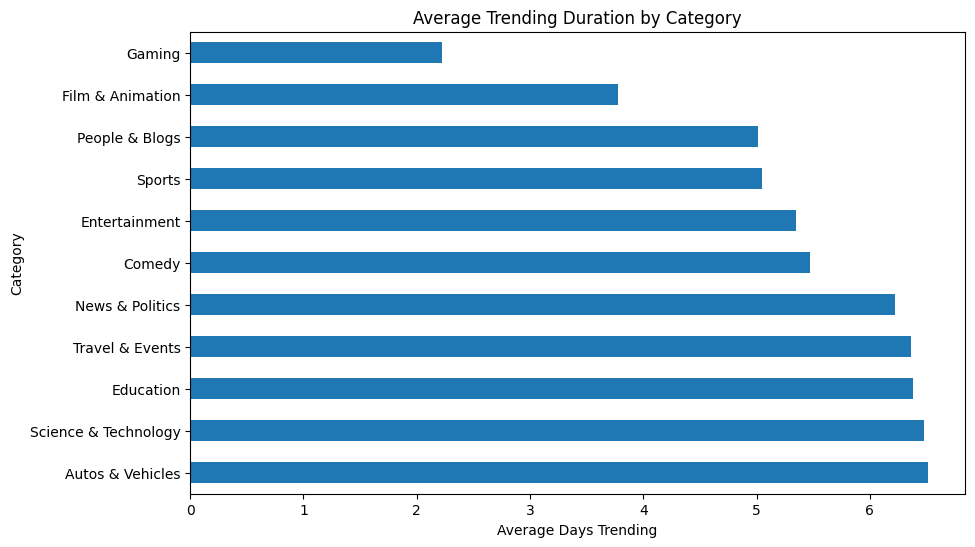

Engagement ratio vs Days trending: -0.015


In [12]:
# Calcular días en tendencia por categoría
category_duration = df_first[df_first['video_category_id'] != 'Pets & Animals'].groupby('video_category_id')['dias_en_tendencia'].mean().sort_values(ascending=False)
category_duration.plot(kind='barh', figsize=(10,6))
plt.xlabel('Average Days Trending')
plt.ylabel('Category')
plt.title('Average Trending Duration by Category')
plt.show()

# Correlación entre engagement y duración en tendencia
corr_engagement_duration = df_first['engagement_ratio'].corr(df_first['dias_en_tendencia'])
print(f"Engagement ratio vs Days trending: {corr_engagement_duration:.3f}")

Although categories with better relative engagement (Comedy, Film & Animation)
also show longer average trending duration, the direct correlation between
engagement_ratio and days_in_trending at the individual video level is
essentially null (-0.015). This suggests that content category influences both
metrics independently, rather than there being a direct causal relationship
between engagement and trending persistence.

Gaming is the most saturated category and, despite dominating in volume, is not
necessarily where a new channel would have the best relative opportunity — there
is more competition for less individual engagement.

Therefore, starting with gaming content would not be the best choice for a new
creator. Instead, categories like Comedy or Film & Animation — which have a
solid number of trending videos and strong engagement — could offer a better
starting point.

## Conclusion

As we observed, although it may be tempting to create gaming or sports content
since these categories dominate the trending list by volume, the data shows
they are not the best choice. These are not the categories where the audience
interacts the most — compared to Comedy and Film & Animation, which, despite
having less competition, achieve a higher proportion of likes and comments per
viewer.

After analyzing the number of tags, video duration, and title length, we infer
that none of these are strong determining factors for whether a video reaches
trending, since their correlations were nearly null and insignificant. There is,
however, a weak tendency for longer titles to perform slightly better than
shorter ones.

Looking at publishing hour, hour 5 initially appeared to have the strongest
influence, but this can't be trusted, as it is skewed by content that doesn't
come from independent creators — specifically, Bollywood content. Excluding
hour 5 and other hours with a similar pattern or insufficient sample size, hour
18 showed the best balance between upload volume and average views.

Regarding video duration, no strong correlation was found; however, we can note
that the Gaming category has the longest videos on average, while also showing
lower relative engagement compared to other categories.

As for title characteristics, the data showed that the most popular videos tend
to have descriptive titles that mention the content and format of the video.
This suggests that, rather than aiming for extravagant or ambiguous titles, it's
more effective to clearly communicate what the video is about — giving viewers
a clear reason to click.

Finally, analyzing trending duration by category confirmed that Gaming is not
the best category to start with, as it has the shortest average trending
duration. Combined with the previous findings, this suggests it isn't the best
starting point for a new channel. In contrast, categories like Comedy and Film &
Animation are less saturated and show a solid percentage of trending duration.